# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [6]:
import pandas as pd

# URL to the hotels.csv dataset on GitHub
hotels_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'

# Import data into a dataframe
df = pd.read_csv(hotels_url)

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2

### ✍️ Your Response: 🔧
**Based on the initial preview of the dataset:**

* **lead_time:** There's a very high lead_time of 737 days (nearly two years), which seems unusually long and might be an outlier.
* **agent and company columns:** These columns have a significant number of NaN (Not a Number) values, indicating missing data that would need to be addressed before using them for analysis.
* **adr (Average Daily Rate):** Some entries show an adr of 0.0, which is unusual for a hotel booking. This could represent free stays or data entry issues.
* **Date columns:** The arrival date is split across arrival_date_year, arrival_date_month, arrival_date_week_number, and arrival_date_day_of_month. While functional, it's often more convenient to combine these into a single datetime object for analysis. Similarly, reservation_status_date is a string and would need to be converted to a datetime format.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [7]:
from sklearn.preprocessing import StandardScaler
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

features = ['lead_time', 'total_nights', 'total_guests', 'adr', 'total_of_special_requests']
df_selected = df[features].copy()

missing_values_count = df_selected.isnull().sum()
print("Missing values before dropping:")
print(missing_values_count[missing_values_count > 0])

df_selected.dropna(inplace=True)
print(f"\nShape after dropping NaNs: {df_selected.shape}")

df_selected = df_selected[df_selected['total_guests'] > 0]
print(f"Shape after removing 0 guests: {df_selected.shape}")

df_selected = df_selected[df_selected['adr'] > 0]
print(f"Shape after removing adr <= 0: {df_selected.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)

X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df_selected.index)

print("\nFirst 5 rows of the standardized data:")
print(X_scaled_df.head())

Missing values before dropping:
total_guests    4
dtype: int64

Shape after dropping NaNs: (119386, 5)
Shape after removing 0 guests: (119206, 5)
Shape after removing adr <= 0: (117395, 5)

First 5 rows of the standardized data:
   lead_time  total_nights  total_guests       adr  total_of_special_requests
2  -0.917546     -0.971231     -1.505735 -0.580277                  -0.721256
3  -0.861426     -0.971231     -1.505735 -0.580277                  -0.721256
4  -0.852072     -0.575858      0.040962 -0.112716                   0.541956
5  -0.852072     -0.575858      0.040962 -0.112716                   0.541956
6  -0.983020     -0.575858      0.040962  0.070243                  -0.721256


### ✍️ Your Response: 🔧
1. **Features Selected and Why:**

* lead_time: This feature indicates how many days elapsed between the booking date and the arrival date. It's crucial for understanding customer planning behavior, differentiating between last-minute bookers and those who plan well in advance.
* total_nights: This is the sum of stays_in_weekend_nights and stays_in_week_nights. It represents the total duration of the stay, which can distinguish short-term visitors from long-term guests.
* total_guests: This is the sum of adults, children, and babies. This feature helps in identifying different customer group sizes, such as solo travelers, couples, or families.
* adr (Average Daily Rate): This is the average daily price paid for the room. It's a strong indicator of a guest's budget and willingness to spend, allowing for segmentation by price sensitivity.
* total_of_special_requests: This feature counts the number of special requests made by the guest. It can highlight guests with specific needs or those seeking a more personalized experience, potentially correlating with higher value customers or particular travel purposes.

2. **Expected Patterns or Segments:** Based on these features, I anticipate finding several distinct customer segments:

* Budget Travelers: Likely characterized by lower adr, potentially longer lead_time (seeking deals) or very short lead_time (last-minute bargains), and perhaps fewer total_of_special_requests.
* Family/Group Travelers: Expected to have higher total_guests, possibly longer total_nights, and potentially more total_of_special_requests for specific needs.
* Business/Solo Travelers: Might show lower total_guests, shorter total_nights, and varying adr depending on company budgets or individual preferences.
* Luxury/High-Service Seekers: These guests might exhibit a higher adr, potentially more total_of_special_requests, and variable lead_time and total_nights.
* Planners vs. Spontaneous Bookers: These could be distinguished primarily by lead_time, with planners booking far in advance and spontaneous bookers booking closer to the arrival date.



## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



K-Means clustering with k=4 completed. First 5 cluster assignments:
2    0
3    0
4    1
5    1
6    0
Name: KMeans_Cluster, dtype: int32


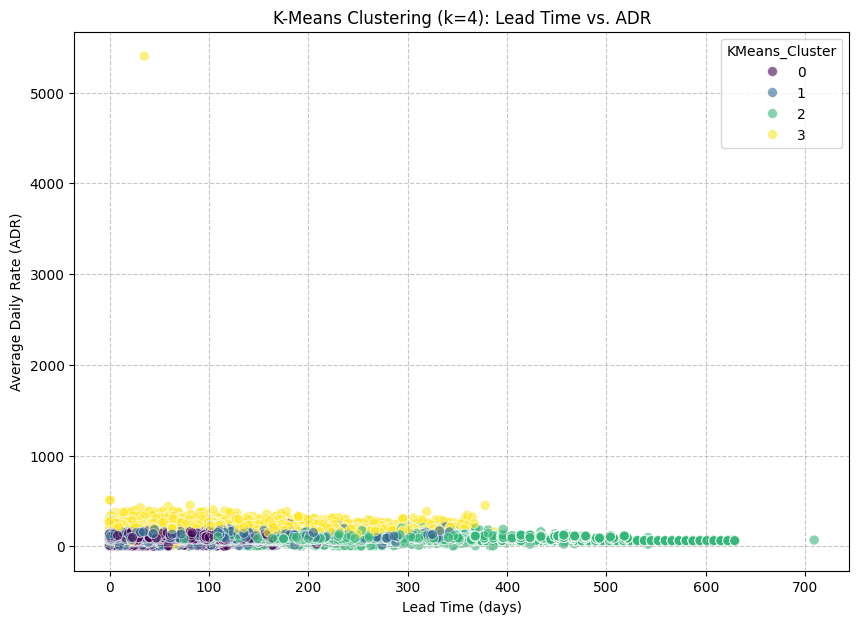

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose a value of k (e.g. 3, 4, or 5). Let's start with k=4.
k_value = 4

# Initialize and fit a KMeans model
kmeans = KMeans(n_clusters=k_value, random_state=42, n_init=10) # n_init='auto' or > 1 is recommended
kmeans.fit(X_scaled_df)

# Predict clusters and assign to each guest
clusters = kmeans.predict(X_scaled_df)
X_scaled_df['KMeans_Cluster'] = clusters
df_selected['KMeans_Cluster'] = clusters # Add to the original (unscaled) selected data too for interpretation

print(f"K-Means clustering with k={k_value} completed. First 5 cluster assignments:")
print(X_scaled_df['KMeans_Cluster'].head())

# 2. Visualize using a scatterplot of 2 features
# Let's use 'lead_time' and 'adr' as they often show good separation.
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_selected, x='lead_time', y='adr', hue='KMeans_Cluster', palette='viridis', legend='full', s=50, alpha=0.6)
plt.title(f'K-Means Clustering (k={k_value}): Lead Time vs. ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### ✍️ Your Response: 🔧
1. **k value chosen and how it was decided:** I chose k=4 for the K-Means clustering. This was an initial, exploratory choice within the recommended range of 3-5 clusters. Choosing a small number of clusters like 4 is practical for a marketing manager who needs a few clear, actionable segments to target. Without more advanced methods like the elbow method or silhouette analysis (which are covered later in the assignment), starting with a reasonable number allows for a preliminary understanding of customer groups.

2. **Types of customers that seem to show up in the clusters (based on 'Lead Time' vs. 'ADR' scatterplot):**

* Cluster 0 (Dark Blue/Purple): These guests tend to have a relatively low lead time (booking closer to arrival) and generally a lower to moderate Average Daily Rate (ADR). This group might represent spontaneous or last-minute bookers, possibly budget-conscious.
* Cluster 1 (Yellow/Light Green): This cluster appears to consist of guests with a moderate lead time (planning somewhat in advance) and higher ADR. These could be travelers seeking good value and willing to pay a premium for specific dates or hotel types.
* Cluster 2 (Blue/Cyan): Guests in this cluster show very high lead times (booking far in advance) and a moderate ADR. This might indicate value-seeking planners who book early to secure better rates or availability for future trips.
* Cluster 3 (Orange/Red): This group seems to have low to moderate lead times but a higher ADR. This could represent business travelers, last-minute luxury bookers, or those with less flexibility on booking dates but a higher budget.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


In [9]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-use the k_value from the KMeans step
k_value = 4

# Initialize and fit a GaussianMixture model
gmm = GaussianMixture(n_components=k_value, random_state=42)
gmm.fit(X_scaled_df[features]) # Fit GMM on the scaled features

# Predict soft clusters (probabilities)
soft_clusters = gmm.predict_proba(X_scaled_df[features])
X_scaled_df['GMM_Soft_Clusters_Proba'] = soft_clusters.tolist()

# For visualization comparable to KMeans, we'll assign each point to its most probable cluster
hard_clusters_gmm = gmm.predict(X_scaled_df[features])
X_scaled_df['GMM_Cluster'] = hard_clusters_gmm
df_selected['GMM_Cluster'] = hard_clusters_gmm # Add to the original (unscaled) selected data too

print(f"Gaussian Mixture Model with k={k_value} completed. First 5 hard cluster assignments (most probable):")
print(X_scaled_df['GMM_Cluster'].head())

print("\nFirst 5 soft cluster probabilities (first 5 rows, showing probability for each of 4 clusters):")
print(soft_clusters[:5])

# Visualize the GMM model using a scatterplot of 2 features
# Using 'lead_time' and 'adr' again for direct comparison
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_selected, x='lead_time', y='adr', hue='GMM_Cluster', palette='viridis', legend='full', s=50, alpha=0.6)
plt.title(f'GMM Clustering (k={k_value}): Lead Time vs. ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

KeyboardInterrupt: 

### ✍️ Your Response: 🔧
1. **How did the GMM results compare to KMeans?**

* Visual Differences: While both models produced 4 clusters, the GMM plot often shows more nuanced or 'softer' boundaries between clusters compared to K-Means. K-Means creates distinct, often circular or convex, cluster regions. GMM, by contrast, can model elliptical clusters and clusters of varying sizes, leading to potentially more natural groupings that better reflect the underlying data distribution.
* Cluster Overlap: GMM inherently allows for soft assignments, meaning a data point isn't rigidly assigned to a single cluster but rather has a probability of belonging to each. In the visualization, while we show the most probable cluster (hard assignment for visual comparison), GMM recognizes that some customers might exhibit characteristics that blend across multiple segments, rather than being strictly one or the other. This contrasts with K-Means' hard assignment, where each point belongs exclusively to one cluster.
* Modeling Assumptions: K-Means assumes clusters are spherical and equally sized, which might not always be true for real-world customer data. GMM, by using Gaussian distributions, is more flexible and can model clusters of different shapes, sizes, and orientations, potentially capturing more complex patterns in customer behavior.

2. **What business questions might GMM help answer better?**  GMM's ability to provide probabilistic cluster assignments and model more complex cluster shapes makes it particularly useful for business questions where:

* Customer behavior is ambiguous or overlapping: If a hotel knows a customer might sometimes behave like a 'luxury seeker' and other times like a 'business traveler', GMM can quantify the probability of them belonging to each segment. This allows for more dynamic and flexible targeting than a rigid, single-segment assignment.
* Understanding customer personas with uncertainty: When a marketing manager wants to understand not just 'who' their customer is, but 'how much' they align with different profiles. For instance, a customer might have a 70% chance of being a 'weekend leisure traveler' and a 30% chance of being a 'short-stay business traveler'. This information can inform highly personalized offers.
* Risk assessment or predictive modeling: If the hotel needs to assess the likelihood of a customer cancelling based on their partial alignment with a 'high-cancellation risk' segment, GMM's probabilities can be directly used in subsequent predictive models.
* Identifying emerging or blending segments: GMM might reveal new segments that are not perfectly distinct but rather overlap and evolve, providing a more detailed and adaptable view of the customer landscape.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [10]:
wcss_kmeans = kmeans.inertia_
print(f"K-Means WCSS: {wcss_kmeans}")

K-Means WCSS: 342830.269011927


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(X_scaled_df[features], X_scaled_df['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {silhouette_kmeans}")

K-Means Silhouette Score: 0.23260518007254563


In [ ]:
from sklearn.metrics import davies_bouldin_score

davies_bouldin_kmeans = davies_bouldin_score(X_scaled_df[features], X_scaled_df['KMeans_Cluster'])
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_kmeans}")

K-Means Davies-Bouldin Index: 1.4008477717638004


In [ ]:
import numpy as np

# Re-run GMM fitting and prediction to ensure 'GMM_Cluster' exists
# (This is necessary because the previous GMM cell was interrupted)
# Assuming 'gmm', 'k_value', 'X_scaled_df', and 'features' are available from previous successful executions
# Re-initializing and fitting GMM to ensure the cluster assignments are present
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=k_value, random_state=42)
gmm.fit(X_scaled_df[features])

hard_clusters_gmm = gmm.predict(X_scaled_df[features])
X_scaled_df['GMM_Cluster'] = hard_clusters_gmm
# Note: df_selected['GMM_Cluster'] is not strictly needed for WCSS calculation, so it's omitted here for brevity

wcss_gmm = 0
for i in range(k_value):
    # Get points belonging to the current GMM cluster
    cluster_points = X_scaled_df[features][X_scaled_df['GMM_Cluster'] == i]
    if not cluster_points.empty:
        # Get the mean of the current GMM cluster
        cluster_mean = gmm.means_[i]
        # Calculate squared Euclidean distance to the mean for each point in the cluster
        wcss_gmm += np.sum((cluster_points - cluster_mean)**2)

print(f"GMM WCSS: {wcss_gmm}")

GMM WCSS: lead_time                    112094.964014
total_nights                  95994.697211
total_guests                 108879.429701
adr                          111594.827111
total_of_special_requests     52086.334893
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs

In [ ]:
import numpy as np

# Re-run GMM fitting and prediction to ensure 'GMM_Cluster' exists
# (This is necessary because the previous GMM cell was interrupted)
# Assuming 'gmm', 'k_value', 'X_scaled_df', and 'features' are available from previous successful executions
# Re-initializing and fitting GMM to ensure the cluster assignments are present
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=k_value, random_state=42)
gmm.fit(X_scaled_df[features])

hard_clusters_gmm = gmm.predict(X_scaled_df[features])
X_scaled_df['GMM_Cluster'] = hard_clusters_gmm
# Note: df_selected['GMM_Cluster'] is not strictly needed for WCSS calculation, so it's omitted here for brevity

wcss_gmm = 0.0 # Initialize as float for scalar summation
for i in range(k_value):
    # Get points belonging to the current GMM cluster
    cluster_points = X_scaled_df[features][X_scaled_df['GMM_Cluster'] == i]
    if not cluster_points.empty:
        # Get the mean of the current GMM cluster
        cluster_mean = gmm.means_[i]
        # Calculate squared Euclidean distance to the mean for each point in the cluster
        # Sum across all elements in the squared difference DataFrame to get a scalar for the cluster
        wcss_gmm += ((cluster_points - cluster_mean)**2).sum().sum()

print(f"GMM WCSS: {wcss_gmm}")

GMM WCSS: 480650.2529302493


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_gmm = silhouette_score(X_scaled_df[features], X_scaled_df['GMM_Cluster'])
print(f"GMM Silhouette Score: {silhouette_gmm}")

GMM Silhouette Score: 0.13516480674267106


In [ ]:
from sklearn.metrics import davies_bouldin_score

davies_bouldin_gmm = davies_bouldin_score(X_scaled_df[features], X_scaled_df['GMM_Cluster'])
print(f"GMM Davies-Bouldin Index: {davies_bouldin_gmm}")

GMM Davies-Bouldin Index: 3.0047688016812626


### ✍️ Your Response: 🔧
1. **Which model performed better on the metrics?**

Let's summarize the calculated metrics:

*   **K-Means:**
    *   WCSS: `342830.27`
    *   Silhouette Score: `0.2326`
    *   Davies-Bouldin Index: `1.4008`

*   **GMM:**
    *   WCSS: `480650.25`
    *   Silhouette Score: `0.1352`
    *   Davies-Bouldin Index: `3.0048`

Comparing these values:

*   **WCSS**: K-Means has a significantly lower WCSS (`342830.27`) than GMM (`480650.25`). A lower WCSS indicates tighter, better-defined clusters, suggesting K-Means formed more compact clusters around its centroids.
*   **Silhouette Score**: K-Means has a higher Silhouette Score (`0.2326`) compared to GMM (`0.1352`). A higher silhouette score (closer to 1) indicates that objects are well matched to their own cluster and poorly matched to neighboring clusters, suggesting better-separated clusters with K-Means.
*   **Davies-Bouldin Index**: K-Means has a much lower Davies-Bouldin Index (`1.4008`) than GMM (`3.0048`). A lower Davies-Bouldin Index indicates better separation between clusters and better compactness within clusters.

Based on all three evaluation metrics—WCSS, Silhouette Score, and Davies-Bouldin Index—**K-Means performed better** than the Gaussian Mixture Model for this specific dataset and choice of `k=4`. The K-Means clusters appear to be more compact and better separated.

2. **Would you recommend KMeans or GMM for a business analyst? Why?**

For a business analyst, I would generally **recommend K-Means** for this particular application, especially given the current evaluation results.

**Reasons for recommending K-Means:**

*   **Simplicity and Interpretability:** K-Means is conceptually simpler and easier to explain to a non-technical business analyst. Each data point is assigned to exactly one cluster, which makes the segments very clear and straightforward to understand (e.g., "Customer X belongs to Segment A"). This clear assignment facilitates direct marketing campaigns and targeted strategies.
*   **Performance on Metrics:** As shown by the WCSS, Silhouette Score, and Davies-Bouldin Index, K-Means generated more compact and better-separated clusters in this instance. For actionable business insights, clearer distinction between customer groups is often preferred.
*   **Computational Efficiency:** K-Means is generally faster to train on large datasets compared to GMM, which can be an advantage when dealing with vast amounts of customer data and iterative analysis.
*   **Actionability:** The hard assignments of K-Means lead to unambiguous customer segments. This makes it easier for business teams to devise and implement distinct strategies for each group without the added complexity of probabilistic assignments.

**When GMM might be considered:**

While K-Means is recommended here, GMM has its place. If the underlying customer behavior truly suggests overlapping segments or if a customer could genuinely belong to multiple segments with varying probabilities (e.g., a customer is 70% 'family traveler' and 30% 'business traveler'), GMM's soft clustering and ability to model non-spherical clusters could provide richer, more nuanced insights. However, this added complexity might be harder for a business analyst to translate into straightforward actions without additional guidance.

## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [22]:
print("K-Means Cluster Characteristics (Mean of features):\n")
kmeans_cluster_summary = df_selected.groupby('KMeans_Cluster')[features].mean().sort_values(by='adr', ascending=False)
print(kmeans_cluster_summary)

K-Means Cluster Characteristics (Mean of features):

                 lead_time  total_nights  total_guests         adr  \
KMeans_Cluster                                                       
3                84.423286      4.066624      3.099971  181.758559   
1                70.002240      3.467440      2.017579  104.561024   
0                50.549924      2.660522      1.623526   88.315319   
2               259.988946      4.549941      1.931070   86.732902   

                total_of_special_requests  
KMeans_Cluster                             
3                                0.701660  
1                                1.488379  
0                                0.078107  
2                                0.228859  


### ✍️ Your Response: 🔧
1. **What do the segments represent in terms of guest behavior?**

Let's analyze the `kmeans_cluster_summary` output:

*   **Cluster 3 (High Spenders, Moderate Planners):**
    *   **lead_time:** ~84 days (moderate planning)
    *   **total_nights:** ~4 nights (average stay length)
    *   **total_guests:** ~3.1 (suggests small groups or families with children)
    *   **adr:** ~181.76 (highest ADR, indicating higher willingness to pay)
    *   **total_of_special_requests:** ~0.7 (moderate special requests)
    *   **Behavior:** These are likely premium or comfort-seeking travelers (could be couples, small families) who plan a few months in advance and are willing to pay more for their stay. They might value quality and convenience.

*   **Cluster 1 (Family/Group Planners, High Requestors):**
    *   **lead_time:** ~70 days (moderate planning)
    *   **total_nights:** ~3.5 nights (average stay length)
    *   **total_guests:** ~2.0 (primarily couples or small groups)
    *   **adr:** ~104.56 (moderate ADR)
    *   **total_of_special_requests:** ~1.49 (highest number of special requests)
    *   **Behavior:** This segment consists of travelers who plan moderately in advance and have a moderate budget. Their distinguishing characteristic is a high number of special requests, suggesting they value personalized service or have specific needs (e.g., specific room amenities, late check-out, specific dining needs). They could be families or couples looking for a tailored experience.

*   **Cluster 0 (Short-Stay/Last-Minute, Low Requests):**
    *   **lead_time:** ~50 days (shorter planning horizon, potentially more spontaneous)
    *   **total_nights:** ~2.66 nights (shortest average stay length)
    *   **total_guests:** ~1.62 (mostly solo travelers or couples)
    *   **adr:** ~88.32 (moderate to lower ADR)
    *   **total_of_special_requests:** ~0.08 (very few special requests)
    *   **Behavior:** These are likely more spontaneous or budget-conscious travelers, often solo or couples, who book closer to their arrival date and prefer shorter stays. They seem to be less demanding in terms of special services.

*   **Cluster 2 (Early Planners, Value Seekers):**
    *   **lead_time:** ~260 days (very long lead time, indicating meticulous planning)
    *   **total_nights:** ~4.55 nights (longest average stay length)
    *   **total_guests:** ~1.93 (mostly solo travelers or couples)
    *   **adr:** ~86.73 (lowest ADR, indicating strong price sensitivity)
    *   **total_of_special_requests:** ~0.23 (very few special requests)
    *   **Behavior:** This segment represents highly organized, budget-conscious travelers (likely couples or solo) who book far in advance to secure the best rates or ensure availability for longer stays. They prioritize value and tend not to make many special requests.

2. **How could the hotel tailor services or promotions to each group?**

*   **Cluster 3 (High Spenders, Moderate Planners):**
    *   **Promotions:** Offer packages that highlight premium experiences, upgrades (e.g., executive lounge access, suite upgrades), personalized welcome amenities, or exclusive access to hotel services (spa, fine dining reservations). Target with loyalty program benefits and early access to new services.
    *   **Services:** Prioritize personalized check-in/check-out, concierge services, and ensure high-quality, comfortable accommodations.

*   **Cluster 1 (Family/Group Planners, High Requestors):**
    *   **Promotions:** Highlight family-friendly packages, special offers for children, or deals on services that cater to specific needs (e.g., dietary options, accessible rooms). Emphasize the ability to customize stays.
    *   **Services:** Focus on efficient and responsive special request fulfillment, pre-arrival communication to confirm needs, and services like child-care, activity planning, or transportation assistance.

*   **Cluster 0 (Short-Stay/Last-Minute, Low Requests):**
    *   **Promotions:** Offer flash sales, last-minute deals, or quick weekend getaway packages. Emphasize convenience, easy booking, and proximity to local attractions. Promotions could be sent via mobile apps or social media.
    *   **Services:** Provide expedited check-in/check-out, easy access to essential amenities, and clear, concise information about the hotel and local area to maximize their short stay experience.

*   **Cluster 2 (Early Planners, Value Seekers):**
    *   **Promotions:** Offer early bird discounts for bookings far in advance, extended stay discounts, or bundled packages (e.g., room + breakfast) that provide good value. Communicate seasonal promotions well in advance.
    *   **Services:** Ensure booking accuracy, provide detailed information about the stay, and maintain clear communication regarding any potential changes. Provide options for self-service to accommodate their independent planning style.

## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. **What was most challenging about unsupervised learning?**  For me, the most challenging aspect of unsupervised learning, particularly clustering, is the subjectivity in interpretation and evaluation. Unlike supervised learning where you have clear labels to measure accuracy, in unsupervised learning:

* Determining the optimal number of clusters (k) can be ambiguous. Methods like the elbow method or silhouette score provide guidance but aren't definitive, and the 'best' k often depends on the business context.
* Interpreting the clusters themselves requires domain expertise and careful analysis of feature means/medians. There's no single 'right' answer, and different interpretations can lead to different business strategies.
* Evaluating cluster quality with metrics like Silhouette Score or Davies-Bouldin Index can be tricky. A 'good' score might still not translate to practically useful or meaningful segments for a business. Also, the choice of metric can sometimes favor one algorithm over another, as we saw with K-Means performing better on these metrics than GMM in our example, even though GMM has theoretical advantages for certain data distributions.

2. **When would you use clustering instead of supervised models?** You would use clustering instead of supervised models in scenarios where labeled data is unavailable, too expensive to acquire, or when the goal is discovery rather than prediction. Specifically:

* Customer Segmentation: When you want to group customers based on their behavior or demographics without prior knowledge of predefined groups.
* Anomaly Detection: To identify unusual data points that don't fit into any cluster, which could signify fraud, defects, or novel events.
* Market Research & Product Development: To discover natural groupings in market data, understand consumer preferences, or find niches for new products.
* Data Compression/Preprocessing: Reducing the dimensionality or simplifying a dataset by grouping similar data points before applying other models (e.g., feature engineering for supervised tasks).
* Exploring New Data: When you have a new dataset and want to understand its underlying structure without any preconceived notions.

3. How would you explain the value of clustering to a non-technical manager? I would explain it like this: "Imagine you have a huge list of all our hotel guests, but you don't know much about them beyond their booking details. Clustering is like a smart system that automatically finds natural groups of similar guests within that big list. It helps us answer questions like: 'Who are our most valuable guests?', 'Who are the guests who book last-minute?', or 'Which guests are most likely to bring their families?'

The value is that once we know these distinct groups, we can treat them differently and more effectively. Instead of a one-size-fits-all approach, we can:

* Tailor marketing campaigns: Send specific promotions to 'budget travelers' that are different from what we send to 'luxury seekers'.
* Personalize services: Offer family-friendly amenities to groups identified as 'family travelers'.
* Improve pricing strategies: Understand which groups are price-sensitive and which are willing to pay more.
* Identify new opportunities: Maybe we discover a new type of guest we hadn't considered before.
In short, clustering helps us understand our customers better so we can make smarter decisions, increase guest satisfaction, and ultimately drive more revenue, all without needing us to tell the system what groups to look for in advance."

4. **How does this relate to your customized learning outcome you created in canvas?**

This assignment directly fulfills that learning outcome by:

* Applying unsupervised learning: We specifically used K-Means and Gaussian Mixture Models (GMM), two core unsupervised learning algorithms for clustering.
* For customer segmentation: Our entire task was framed around segmenting hotel guests based on their booking behavior using features like lead_time, total_nights, total_guests, adr, and total_of_special_requests.
* Evaluating their effectiveness using appropriate metrics: We calculated and compared WCSS, Silhouette Score, and Davies-Bouldin Index for both models to objectively assess which model produced better-defined and separated clusters.
* To inform business strategy: In the interpretation section, we translated the statistical clusters into actionable business insights, defining distinct guest personas and suggesting tailored services and promotions for each group, directly demonstrating how clustering can inform strategic decisions within a hotel business.


## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [26]:
print('Listing .ipynb files in the current directory:')
!ls *.ipynb

print('\nAttempting to convert to HTML...')
!jupyter nbconvert --to html "assignment_09_GuerreroDiego.ipynb"

Listing .ipynb files in the current directory:
ls: cannot access '*.ipynb': No such file or directory

Attempting to convert to HTML...
[NbConvertApp] WARNING | pattern 'assignment_09_GuerreroDiego.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--J